In [1]:
1+1

2

## Basic chatbot using graphAPI

In [2]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END

from langgraph.graph.message import add_messages #this is a reducer
#the work of a reducer is to append information inside state rather than replace it


 

In [3]:
class State(TypedDict):
    messages:Annotated[list,add_messages] #here the messagesmake thelist and it uses reducer



In [4]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-120b")


In [6]:
#this bascally is my node functionality 
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder=StateGraph(State)

#adding node
graph_builder.add_node("llmchatbot", chatbot) 

#adding edge
graph_builder.add_edge(START, 'llmchatbot')
graph_builder.add_edge('llmchatbot', END)

In [8]:
#compile graph

graph=graph_builder.compile()

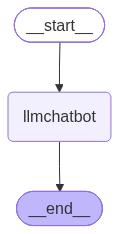

In [9]:
## visual of grapoh

from IPython.display import Image,display

display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
#needed to put mesages to invoke 
response = graph.invoke({"messages":"Yo"})

In [11]:
response['messages'][-1].content

'Hey there! How can I help you today?'

In [12]:
#more ways to stream 
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing great, thanks for asking. How can I assist you today?


## Chatbot with tool


In [13]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 3)
response = tool.invoke("what is langgraph")


In [14]:
response

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norweg

In [15]:
#custom function

def multiply(a:int , b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [16]:
tools = [tool,multiply]

In [17]:
llm_with_tools = llm.bind_tools(tools)

In [18]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x127d71e80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x127d72ba0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted res

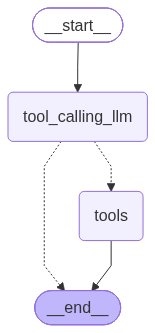

In [19]:
#stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#state
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#node
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges 
builder.add_edge(START,"tool_calling_llm") #tool
#here i need conditional edge that whether to call tool or not 
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [20]:
response = graph.invoke({"messages":"what is current job market"})

In [21]:
response['messages'][-1].content

'{"query": "2024 2025 2026 job market trends unemployment rate hiring trends sectors growth", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.naceweb.org/job-market/trends-and-predictions", "title": "Trends & Predictions - Job Market", "content": "## Data Bites\\n\\n### 4.1%\\n\\nOverall unemployment rate\\n\\nBureau of Labor Statistics\\n\\n#### 8.1% (July 2026)/ 8.5% (July 2025)/\\n\\nUnemployment rate, bachelor’s degree grads age 20 – 24\\n\\nBureau of Labor Statistics\\n\\n### 5.6%\\n\\nProjected increase in hiring for Class of 2026\\n\\n2026 Job Outlook Spring Update\\n\\n### 60.3%\\n\\nPercent employed overall, Class of 2024 bachelor\'s degree graduates\\n\\nDashboard—First Destinations for the Class of 2024\\n\\n## Job Network\\n\\nView All [...] The small dip in college hiring revealed by NACE’s Job Outlook 2024 survey is down from the last two years, when the college job market experienced brisk growth that, in 2022, reached record l

In [22]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is current job market
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_a50ac88f-31f8-43a1-87f8-509f243e780f)
 Call ID: fc_a50ac88f-31f8-43a1-87f8-509f243e780f
  Args:
    query: 2024 2025 2026 job market trends unemployment rate hiring trends sectors growth
    search_depth: advanced
    time_range: year
================================= Tool Message =================================
Name: tavily_search

{"query": "2024 2025 2026 job market trends unemployment rate hiring trends sectors growth", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.naceweb.org/job-market/trends-and-predictions", "title": "Trends & Predictions - Job Market", "content": "## Data Bites\n\n### 4.1%\n\nOverall unemployment rate\n\nBureau of Labor Statistics\n\n#### 8.1% (July 2026)/ 8.5% (July 2025)/\n\nUnemployment rate,

In [23]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================

5 multiplied by 2 equals **10**.


In [24]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_f0d693c4-a6f7-4e66-b0d1-10044c77cdea)
 Call ID: fc_f0d693c4-a6f7-4e66-b0d1-10044c77cdea
  Args:
    query: latest AI news September 2026
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Security and AI news from the three weeks beginning 3 ...", "url": "https://www.enterprisetimes.co.uk/2026/08/27/security-and-ai-news-from-the-three-weeks-beginning-3-august-2026", "content": "DigiCert hosts World Quantum Readiness Day on September 17, 2026. Registration for this free virtual event is now open. The firm just announced a r

### yeah so here without react, it just used one tool nothing else

In [25]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_7654a4bb-09e7-4038-85d2-703dca488a8e)
 Call ID: fc_7654a4bb-09e7-4038-85d2-703dca488a8e
  Args:
    query: latest AI news September 2026
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "Security and AI news from the three weeks beginning 3 ...", "url": "https://www.enterprisetimes.co.uk/2026/08/27/security-and-ai-news-from-the-three-weeks-beginning-3-august-2026", "content": "DigiCert hosts World Quantum Readiness Day on September 17, 2026. Registration for this free virtual event is now open. The firm just announced a r

### now we use the react agent architecture

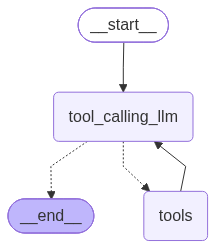

In [26]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_b275a05c-6ea6-4bfc-9f40-4fe7763df693)
 Call ID: fc_b275a05c-6ea6-4bfc-9f40-4fe7763df693
  Args:
    query: latest AI news August 2026
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news August 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.instagram.com/p/DbuuejQqrE3", "title": "Instagram", "content": "Top 5 AI News Today | 07 August 2026   \n  \nThe next wave of AI is all about memory, regulation, affordability, and more powerful models. Today's biggest headlines show how AI is becoming smarter, safer, and more accessible across the globe.  \n  \nToday's Highlights:  

## Adding memory

langraph has dictionary to add checkpoint memory built in itself

In [28]:
response=graph.invoke({"messages":"Hello my name is Yash"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Yash
================================== Ai Message ==================================

Nice to meet you, Yash! 👋 How can I assist you today?


In [29]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don’t have any record of your name from our conversation so far. If you’d like me to address you by name, just let me know what it is!


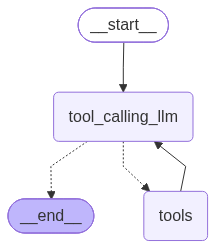

In [32]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
   
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

##adding memory here
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
#we give a thread id that is unique 
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Yash"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Yash', additional_kwargs={}, response_metadata={}, id='28bd40e7-da56-46cf-b329-fbf756e278da'),
  AIMessage(content='Hello Yash! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hi my name is Yash". Probably they are greeting. I should respond politely, ask how can I help.'}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 348, 'total_tokens': 401, 'completion_time': 0.114622048, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.01714229, 'prompt_tokens_details': None, 'queue_time': 0.316237229, 'total_time': 0.131764338}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_64b2f1c926', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a05685-45ae-7f52-9998-ec20ed5708ae-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 348, 'output_token

In [34]:
response['messages'][-1].content

'Hello Yash! Nice to meet you. How can I assist you today?'

In [35]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Yash.


## Streaming
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

- values : This streams the full state of the graph after each node is called.
- updates : This streams updates to the state of the graph after each node is called.

In [36]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [37]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

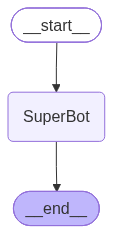

In [38]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [40]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is yash And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='eda189f7-bb7e-4247-a0eb-9158b384d404'),
  AIMessage(content='Hi Krish! 👋 Nice to meet you.  \n\nIt’s great to hear you’re into cricket. Do you have a favorite team or player? Are you more into watching the matches, playing the game yourself, or maybe both? Let me know—I’d love to chat about anything cricket‑related!', additional_kwargs={'reasoning_content': 'We need to respond. The user says hi, introduces themselves. Probably respond friendly, ask about cricket preferences, etc. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 82, 'total_tokens': 182, 'completion_time': 0.215022742, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.00320887, 'prompt_tokens_details': None, 'queue_time': 0.366572383, 'total_time': 0.218231612}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_803

### below we used mode=update

In [41]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Yash And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Yash! Great to meet you. 🎉\n\nCricket’s such a fun sport—do you have a favorite team or player? Are you more into watching the matches, playing yourself, or maybe both? Let me know what you enjoy most about the game!', additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Yash And I like cricket". Probably they want a response. The system says we should respond as ChatGPT. There\'s no disallowed content. So just greet, ask about cricket preferences.'}, response_metadata={'token_usage': {'completion_tokens': 113, 'prompt_tokens': 82, 'total_tokens': 195, 'completion_time': 0.233903946, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.003532111, 'prompt_tokens_details': None, 'queue_time': 0.367245118, 'total_time': 0.237436057}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq

### and here we uses mode=values which gave us human as well as ai messages too, appended rather than update

In [42]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Yash And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Yash And I like cricket', additional_kwargs={}, response_metadata={}, id='14372497-57d3-4268-aa42-e04a836bbee6'), AIMessage(content='Hey Yash! Great to meet you. 🎉\n\nCricket’s such a fun sport—do you have a favorite team or player? Are you more into watching the matches, playing yourself, or maybe both? Let me know what you enjoy most about the game!', additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Yash And I like cricket". Probably they want a response. The system says we should respond as ChatGPT. There\'s no disallowed content. So just greet, ask about cricket preferences.'}, response_metadata={'token_usage': {'completion_tokens': 113, 'prompt_tokens': 82, 'total_tokens': 195, 'completion_time': 0.233903946, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.003532111, 'prompt_tokens_details': None, 'queue_time': 0.367245118, 'total_time': 0.237436057}, 'model_name': 'openai/gpt-oss-120b

In [43]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Yash And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hi Yash! 👋 Great to meet you.  \n\nCricket’s such a fun sport—whether you’re into the fast‑paced excitement of T20s, the strategic depth of Test matches, or the classic drama of ODIs. Do you have a favorite format, team, or player you follow? If you’re looking for any stats, recent match highlights, or just want to chat about the game, let me know! 🏏✨', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Yash And I like cricket". Likely they want a response, maybe a greeting and conversation about cricket. The system instructions: we must respond normally, no disallowed content. So we can greet Yash, ask about his cricket preferences. Possibly ask which team, player, etc. Also we can share some cricket info. We\'ll keep it friendly.'}, response_metadata={'token_usage': {'completion_tokens': 182, 'prompt_tokens': 82, 'total_tokens': 264, 'completion_time': 0.383441776, 'completion_tokens_details': {'reasoning_tokens': 81},

In [44]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Yash And I like cricket', additional_kwargs={}, response_metadata={}, id='09d762fd-37ce-414a-a31d-ac5c597d305b'), AIMessage(content='Hi Yash! 👋 Great to meet you.  \n\nCricket’s such a fun sport—whether you’re into the fast‑paced excitement of T20s, the strategic depth of Test matches, or the classic drama of ODIs. Do you have a favorite format, team, or player you follow? If you’re looking for any stats, recent match highlights, or just want to chat about the game, let me know! 🏏✨', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Yash And I like cricket". Likely they want a response, maybe a greeting and conversation about cricket. The system instructions: we must respond normally, no disallowed content. So we can greet Yash, ask about his cricket preferences. Possibly ask which team, player, etc. Also we can share some cricket info. We\'ll keep it friendly.'}, response_metadata={'token_usage': {'completion_token

In [45]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Yash and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Yash and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a05794-2bc0-74e2-acc2-ae6828e8b221', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Yash and I like to play cricket', additional_kwargs={}, response_metadata={}, id='d59f54a7-75fd-47b0-a30b-fb130ecdf990')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a05794-2bc5-7d70-b924-f701ce5a2757', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:60354e6e-3e79-3c4f-a021-701da78de7c3'}, 'parent_ids': ['01a05794-2bc0-74e2-acc2-ae6828e8b221']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [